In [347]:
from Bio import SeqIO
from Bio.Seq import Seq
import numpy as np
import re
from matplotlib import pyplot as plt

In [296]:
mutants=[]
with open("all_mutations.csv") as f:
    for l in f:
        mutants.append(l.strip().split(','))
print(mutants[0])
mutants=mutants[1:]

['ï»¿Date of sequencing', 'Barcode#', 'Date of experiment ', 'Culture (& cfu# or strain)', 'Gene', 'Mutation', 'Mode of selection']


In [271]:
mutants[0:4]

[['20230405', '1', '20230124', '0_EEL02', 'rpsL', 'K43T', 'In turbidostat'],
 ['20230405', '2', '20230126', '0_AD30', 'rpsL', 'K43T', 'In turbidostat'],
 ['20230405', '3', '20230126', '3_AD30', 'rpsL', 'K88R', 'In turbidostat'],
 ['20230405', '4', '20230214', '1_EEL02', 'rpsL', 'K43T', 'In turbidostat']]

In [212]:
#mutants=[m for m in mutants if m[0]=='20220921']
#print(mutants)

In [288]:
vcf=[]
with open("20220921/snps_regions_mincov5.vcf") as f:
    for l in f:
        vcf.append(["20220921"]+l.strip().split(' '))
with open("20221208/snps_regions_mincov5.vcf") as f:
    for l in f:
        vcf.append(["20221208"]+l.strip().split(' '))      
with open("20230405/snps_regions_mincov5.vcf") as f:
    for l in f:
        vcf.append(["20230405"]+l.strip().split(' '))    
with open("20230711/snps_regions_mincov5.vcf") as f:
    for l in f:
        vcf.append(["20230711"]+l.strip().split(' '))  
with open("20220701/snps_regions_mincov5.vcf") as f:
    for l in f:
        vcf.append(["20220701"]+l.strip().split(' '))  
with open("20231011/snps_regions_mincov5.vcf") as f:
    for l in f:
        vcf.append(["20231011"]+l.strip().split(' '))  

In [258]:
vcf[-4:]

[['20231011', 'sample40', '2338434', 'A', 'T', '377.804'],
 ['20231011', 'sample40', '2339162', 'C', 'T', '367.497'],
 ['20231011', 'sample41', '3878729', 'G', 'A', '203.81'],
 ['20231011', 'sample42', '2339173', 'G', 'A', '284.842']]

In [322]:
indels=[]
with open("20230405/dels.vcf") as f:
    for l in f:
        indels.append(["20230405"]+l.strip().split(' '))    

In [313]:
indels[0:4]

[['20230405', 'sample25', '258675', 'C', '<DEL>', '415426', '1920'],
 ['20230405',
  'sample25',
  '1097525',
  'A',
  'AAAAAAGCCCGTACTTTCGTACGAGCTCTTCTTTAAATATGGCGGTGAGGGGGGATTGACTCGCTTCGCTCGCCCTGCGGGCAGCCCGCTCACTGCGTTCACGGTTCGTCCAACTGGCTGTCGCCAGTTGTCGAACCCCGGTCGGGGCTTCTCATCCCCCCGGTGTGTGCAATATACG',
  '1097526',
  '540'],
 ['20230405', 'sample25', '1207789', 'C', '<INV>', '1209618', '168'],
 ['20230405',
  'sample25',
  '1873030',
  'G',
  'GCGGATGCACGGTAATGACTCCAACTTATTGATAGTGTTTTATGTTCAGATAATGCCCGATGACTTTGTCATGCAGCTCCACCGATTTTGAGAACGACAGCGACTTCCGTCCCAGCCGTGCCAGGTGCTGCCTCAGATTCAGGTTATGCCGCTCAATTCGCTGCGTATATCGCTTGCTGATTACGTGCAGCTTTCCCTTCAGGCGGGATTCATACAGCGGCCAGCCATCCGTCATCCATATCACCACGTCAAAGGGTGACAGCAGGCTCATAAGACGCCCCAGCGTCGCCATAGTGCGTTCACCGAATACGTGCGCAACAACCGTCTTCCGGAGACTGTCATACGCGTAAAACAGCCAGCGCTGGCGCGATTTAGCCCCGACATAGCCCCACTGTTCGTCCATTTCCGCGCAGACGATGACGTCACTGCCCGGCTGTATGCGCGAGGTTACCGACTGCGGCCTGAGTTTTTTAAGTGACGTAAAATCGTGTTGAGGCCAACGCCCATAATGCGGGCTGTTGCCCGGCATCCAACGCCATTCATGGCCATATCAAT

In [190]:
strain=[]
with open("GCF_000005845.2_ASM584v2_cds_from_genomic.fna") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        #if ("protease" in record.description) or ("peptidase" in record.description):
        #    i=i+1
        #    print(i," ",record.description[0:120])
        s=record.description
        match = re.search(r"\[location=(?:complement\()?(\d+)\.\.(\d+)\)?\]", s)
        if match:
            start, end = map(int, match.groups())
        else:
            start,end=-1,-1
        gene_name=s.split(' ')[1][6:-1]
        if 'complement' in s: # reverse if complemental sequence is stored, this will be important when searching for SNPs and translating into AAS
            strain.append([gene_name,start,end,record.seq.reverse_complement(),-1])
        else:
            strain.append([gene_name,start,end,record.seq,1])

In [113]:
'complement' in '[location=complement(5683..6459)] [gbkey=CDS]'

False

In [191]:
str(strain[0])

"['thrL', 190, 255, Seq('ATGAAACGCATTAGCACCACCATTACCACCACCATCACCATTACCACAGGTAAC...TGA'), 1]"

In [141]:
first_diff_index('xxx','xAx')

1

In [171]:
str(seq.translate())[1]

'F'

In [289]:
def first_diff_index(a, b):
    for i, (x, y) in enumerate(zip(a, b)):
        if x != y:
            return i
    if len(a) != len(b):
        return min(len(a), len(b))
    return -1  # identical

mutants_BW=[]
for snp in vcf:
    pos=int(snp[2])
    ref,alt=snp[3],snp[4]
    genes,aas='',''
    for g,start,end,seq,rev in strain:
        if pos>=start and pos<=end:
            genes=g # .apppend(g[0])
            
            if len(ref)==len(alt): # SNP only but not necessarily only one bp (can be >1)
                #print(str(seq)[pos-start])
                alt_seq=str(seq)
                alt_seq=alt_seq[:pos-start]+alt+alt_seq[pos-start+len(alt):]
                if (rev==-1): # if complementary DNA sequence was reversed, we must reverse-complement to get the correct coding sequence
                    aa=str(seq.reverse_complement().translate())
                    alt_aa=str(Seq(alt_seq).reverse_complement().translate())
                else:
                    aa=str(seq.translate())
                    alt_aa=str(Seq(alt_seq).translate())
                #print(aa,alt_aa)
                #print(str(seq)[pos-start],str(alt_seq)[pos-start])
                #print(len(aa),len(alt_aa))
                #if aa==alt_aa:
                #    print("true")
                ind=first_diff_index(aa,alt_aa)
                aas=(aa[ind]+str(ind+1)+alt_aa[ind])
            break
    mutants_BW.append([snp[0],snp[1][6:],genes,snp[2],ref,alt,aas])

In [295]:
mutants_BW

[['20220921', '01', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '02', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '03', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '04', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '05', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '05', 'rpoB', '4181265', 'GAAAAAACG', 'GAAAAACG', ''],
 ['20220921', '06', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '07', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '08', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '09', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '10', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '10', 'parC', '3165787', 'ATTTTTTAAATTTG', 'ATTTTTAAATTTG', ''],
 ['20220921', '11', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '12', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '13', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '14', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '15', 'gyrA', '2339162', '

## compare Elin's list and my list

In [232]:
mutants[0:4]

[['20230405', '1', '20230124', '0_EEL02', 'rpsL', 'K43T', 'In turbidostat'],
 ['20230405', '2', '20230126', '0_AD30', 'rpsL', 'K43T', 'In turbidostat'],
 ['20230405', '3', '20230126', '3_AD30', 'rpsL', 'K88R', 'In turbidostat'],
 ['20230405', '4', '20230214', '1_EEL02', 'rpsL', 'K43T', 'In turbidostat']]

In [233]:
mutants_BW[0:4]

[['20220921', '01', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '02', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '03', 'gyrA', '2339162', 'C', 'A', 'D87Y'],
 ['20220921', '04', 'gyrA', '2339162', 'C', 'A', 'D87Y']]

In [297]:
for m in mutants:
    m2=[[mbw[2],mbw[6]] for mbw in mutants_BW if (mbw[0]==m[0] and int(mbw[1])==int(m[1]))]
    txt=str(m)+" "+str(m2)
    #print("\033[31mThis is red text\033[0m")
    if ((len(m2)>0 and (m[5] not in str(m2))) or len(m2)==0):
        print("\033[31m"+txt+"\033[0m")        
    else:
        print(txt)

['20230405', '1', '20230124', '0_EEL02', 'rpsL', 'K43T', 'In turbidostat'] [['rpsL', 'K43T']]
['20230405', '2', '20230126', '0_AD30', 'rpsL', 'K43T', 'In turbidostat'] [['rpsL', 'K43T']]
['20230405', '3', '20230126', '3_AD30', 'rpsL', 'K88R', 'In turbidostat'] [['rpsL', 'K88R']]
['20230405', '4', '20230214', '1_EEL02', 'rpsL', 'K43T', 'In turbidostat'] [['rpsL', 'K43T']]
['20230405', '5', '20230214', '2_EEL02', 'rpsL', 'K43T', 'In turbidostat'] [['rpsL', 'K43T']]
['20230405', '6', '20230123', '0_1', 'rpsL', 'K43R', 'Agar plate'] [['rpsL', 'K43R']]
['20230405', '25', '20230123', '0_SCV_EEL02', 'hemB', 'deletion', 'Agar plate'] []
['20230405', '26', '20230123', '0_SCV_AD30', 'hemB', 'deletion ', 'Agar plate'] []
['20230405', '27', '20230123', '3_SCV_EEL02', 'hemB', 'deletion', 'Agar plate'] []
['20220701', '3', '20220610', '0_EEL02', 'rpoB', 'H526N', 'In turbidostat'] [['rpoB', 'H526N']]
['20220701', '4', '20220610', '1_AD30', 'rpoB', 'S512P', 'In turbidostat'] [['rpoB', 'S512P']]
['2022

# InDels

In [323]:
indels[0:4]

[['20230405',
  'sample01',
  '1097162',
  'A',
  'AAAAAAAGCCCGTACTTTCGTACGAGCTCTTCTTTAAATATGGCGGTGAGGGGGGATTGACTCGCTTCGCTCGCCCTGCGGGCAGCCCGCTCACTGCGTTCACGGTCTGTCCAACTGGCTGTCGCCAGTTGTCGAACCCCGGTCGGGGCTTCTCATCCCCCGGTGTGTGCAATATACG',
  '1097163',
  '600'],
 ['20230405',
  'sample01',
  '1097398',
  'G',
  'GATTGACTCGCTTCGCTCGCCCTGCGGGCAGCCCGCTCACTGCGTTCACGGTCTGTCCAACTGGCTGTCGCCAGTTGTCGAACCCCGGTCGGGGCTTCTCATCCCCGGTGTGTGCAATATACGAAAAAAGCCCGTACTTTCGTACGAGCCTCTTCTTTAAATATGGCGGTGAGGA',
  '1097399',
  '420'],
 ['20230405', 'sample01', '1207789', 'C', '<INV>', '1209618', '886'],
 ['20230405', 'sample01', '1207806', 'A', '<INV>', '1209603', '646']]

In [330]:
def whatitis(desc):
    if len(desc)<10:
        return desc
    else:
        return "?INS?"
[[s[0],s[1],s[2],whatitis(s[4]),int(s[5])-int(s[2])] for s in indels]

[['20230405', 'sample01', '1097162', '?INS?', 1],
 ['20230405', 'sample01', '1097398', '?INS?', 1],
 ['20230405', 'sample01', '1207789', '<INV>', 1829],
 ['20230405', 'sample01', '1207806', '<INV>', 1797],
 ['20230405', 'sample01', '1411899', '<DUP>', 23059],
 ['20230405', 'sample01', '1873030', '?INS?', 1],
 ['20230405', 'sample01', '4296269', 'G', 112],
 ['20230405', 'sample01', '4543181', 'G', 431],
 ['20230405', 'sample02', '1097575', '?INS?', 1],
 ['20230405', 'sample02', '1207789', '<INV>', 1829],
 ['20230405', 'sample02', '1873030', '?INS?', 1],
 ['20230405', 'sample02', '4296103', 'A', 113],
 ['20230405', 'sample02', '4543194', 'C', 444],
 ['20230405', 'sample03', '1097212', '?INS?', 1],
 ['20230405', 'sample03', '1207789', '<INV>', 1829],
 ['20230405', 'sample03', '1207806', '<INV>', 1797],
 ['20230405', 'sample03', '1611622', '?INS?', 1],
 ['20230405', 'sample03', '1873030', '?INS?', 1],
 ['20230405', 'sample03', '1973846', 'C', 4657],
 ['20230405', 'sample03', '4296269', 'G'

### genes that are affected by deletions:

In [328]:
i=0
for s in indels:
    if s[4]=="<DEL>":
        p1,p2=int(s[2]),int(s[5])
        #genes,aas='',''
        for g,start,end,seq,rev in strain:
            if (p1<=end) and (start<p2):
                print(i,s[1],g,start,end)
                i=i+1
                #genes=g # .apppend(g[0])

0 sample25 phoE 259045 260100
1 sample25 proB 260388 261491
2 sample25 proA 261503 262756
3 sample25 ykfN 263150 263212
4 sample25 ykfI 263328 263669
5 sample25 yafW 263690 264007
6 sample25 ykfH 264026 264247
7 sample25 ykfG 264256 264732
8 sample25 yafX 264748 265206
9 sample25 ykfF 265304 265543
10 sample25 ykfB 265620 266087
11 sample25 yafY 266110 266553
12 sample25 yafZ 267184 268005
13 sample25 ykfA 268097 268960
14 sample25 perR 269289 270182
15 sample25 insI-1 270603 271754
16 sample25 ykfC 272847 273992
17 sample25 insH-1 274101 275117
18 sample25 mmuP 275325 276728
19 sample25 mmuM 276715 277647
20 sample25 afuC 277756 278802
21 sample25 afuB 278814 279162
22 sample25 insB-2 279178 279681
23 sample25 insA-2 279600 279875
24 sample25 yagB 280385 280735
25 sample25 yagA 280829 281983
26 sample25 yagE 282278 283186
27 sample25 yagF 283201 285168
28 sample25 yagG 285395 286777
29 sample25 yagH 286789 288399
30 sample25 xynR 288404 289162
31 sample25 argF 289301 290305
32 sample2

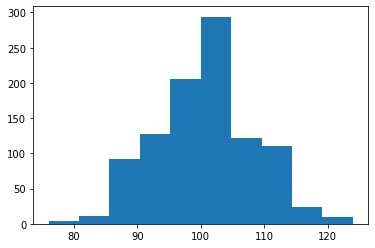

In [358]:
def one_run():
    n=100
    k=100.
    alpha=0.5
    beta=0.5
    for i in range(100):
        tot_rate=alpha*n+beta*n*(n/k)
        x=np.random.rand()*tot_rate
        if x<alpha*n:
            n=n+1
        else:
            n=n-1
            if n<=0: break
    return n
tmp=[one_run() for i in range(1000)]
plt.hist(tmp)
plt.show()

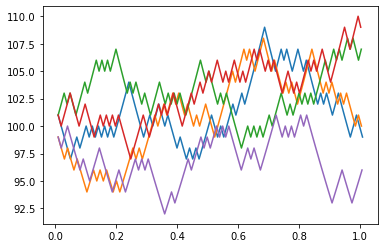

In [415]:
def one_run(alpha=0.5,beta=0.5,tmax=1,k=100.):
    n=int(k)
    t=0
    history=[]
    while t<tmax:
        tot_rate=alpha*n+beta*n*(n/k)
        x=np.random.rand()*tot_rate
        t=t+1/tot_rate
        if x<alpha*n:
            n=n+1
        else:
            n=n-1
            if n<=0: break
        history.append([t,n])
    return history

tmp=[np.array(one_run()) for i in range(5)]
for tr in tmp:
    #print (tr)
    plt.plot(tr[:,0],tr[:,1])
plt.show()

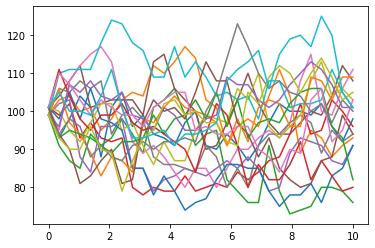

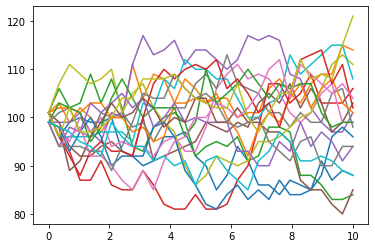

In [402]:
tts=np.linspace(0,10,30)
for i in range(20):
    tr=np.array(one_run(tmax=10))
    y=np.interp(tts,tr[:,0],tr[:,1]).astype(int)
    plt.plot(tts,y)
plt.show()

for i in range(20):
    tr=np.array(one_run(alpha=0.2,beta=0.2,tmax=10))
    y=np.interp(tts,tr[:,0],tr[:,1]).astype(int)
    plt.plot(tts,y)
plt.show()

7.032255841635898
4.063326497123044


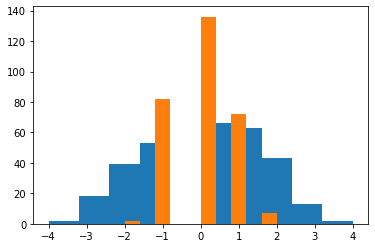

In [427]:
tts=np.linspace(0,10,30*10)
tr=np.array(one_run(tmax=10,k=100))
y=np.interp(tts,tr[:,0],tr[:,1]).astype(int)
plt.hist(np.diff(y))
print(np.std(y))

tr=np.array(one_run(tmax=10,k=100,alpha=0.2,beta=0.2))
y=np.interp(tts,tr[:,0],tr[:,1]).astype(int)
plt.hist(np.diff(y))
print(np.std(y))

plt.show()